# Prior Model Verification: XGBoost vs Kalshi Pregame Odds

Compare our XGBoost prior (pre-game) win probability models against Kalshi
market-implied pregame odds for all 2025-26 NBA games where Kalshi data is available.

We evaluate two models:
1. **Research model** (`xgboost_prior.pkl`) — trained on seasons up to 2022-23, val=2023-24, test=2024-25
2. **Deploy model** (`xgboost_prior_deploy.pkl`) — retrained on last 6 seasons (2019-20 through 2025-26)

Kalshi pregame odds are extracted as the median implied probability from the first
5 minutes of Kalshi market data (before PBP tipoff).

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import json

from sklearn.metrics import (
    accuracy_score, log_loss, brier_score_loss, roc_auc_score,
    precision_score, recall_score, f1_score
)

DATA_DIR = Path('data')
MODEL_DIR = Path('prior_models')
KALSHI_DIR = DATA_DIR / 'kalshi_live'

print(f'Data: {DATA_DIR.resolve()}')
print(f'Models: {MODEL_DIR.resolve()}')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Data: /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/data
Models: /Users/danielyang/Desktop/Extra_Curriculars/kalshi-bot/nba/prior_models


## Step 1 — Load Models and Predictions

In [17]:
# Load pre-computed predictions from both models
preds_research = pd.read_csv(DATA_DIR / 'games_predictions.csv', dtype={'game_id': str})
preds_research['game_date'] = pd.to_datetime(preds_research['game_date'])
preds_research['game_id'] = preds_research['game_id'].str.strip()

preds_deploy = pd.read_csv(DATA_DIR / 'games_predictions_deploy.csv', dtype={'game_id': str})
preds_deploy['game_date'] = pd.to_datetime(preds_deploy['game_date'])
preds_deploy['game_id'] = preds_deploy['game_id'].str.strip()

# Filter to 2025-26 season
preds_research_26 = preds_research[preds_research['game_date'] >= '2025-10-01'].copy()
preds_deploy_26 = preds_deploy[preds_deploy['game_date'] >= '2025-10-01'].copy()

print(f'Research model 2025-26 predictions: {len(preds_research_26)}')
print(f'Deploy model 2025-26 predictions: {len(preds_deploy_26)}')

# Merge into one df
df = preds_research_26[['game_id', 'game_date', 'home_team', 'away_team',
                         'prior_home_wp', 'home_win_actual', 'score_diff']].copy()
df = df.rename(columns={'prior_home_wp': 'p_research'})

deploy_map = preds_deploy_26.set_index('game_id')['prior_home_wp']
df['p_deploy'] = df['game_id'].map(deploy_map)
df = df.dropna(subset=['p_deploy'])

print(f'Merged games: {len(df)}')

Research model 2025-26 predictions: 835
Deploy model 2025-26 predictions: 835
Merged games: 835


## Step 2 — Extract Kalshi Pregame Implied Odds

For each game, we take the Kalshi market data and compute the median implied
home win probability from the first 5 minutes of trading data.
This represents the market's pregame consensus.

In [18]:
def get_kalshi_pregame(game_id):
    """Extract pregame implied home win probability from Kalshi data."""
    paths = list(KALSHI_DIR.glob(f'{game_id}_*_kalshi_*.csv'))
    if not paths:
        return np.nan
    
    k = pd.read_csv(paths[0])
    k['timestamp'] = pd.to_datetime(k['timestamp'], format='ISO8601', utc=True)
    
    # Compute implied home win prob from each row
    home_mid = (k['home_high_cents'] + k['home_low_cents']) / 2
    away_mid = (k['away_high_cents'] + k['away_low_cents']) / 2
    
    implied = np.where(
        k['home_volume'] > 0, home_mid,
        np.where(k['away_volume'] > 0, 1 - away_mid, np.nan)
    )
    k['implied'] = implied
    k = k.dropna(subset=['implied'])
    
    if len(k) < 3:
        return np.nan
    
    # Take first 5 minutes of data as "pregame"
    t0 = k['timestamp'].iloc[0]
    pregame = k[k['timestamp'] <= t0 + pd.Timedelta(minutes=5)]
    
    if len(pregame) < 2:
        # Fall back to first 10 rows
        pregame = k.head(10)
    
    return float(pregame['implied'].median())


# Get Kalshi pregame odds for all games
kalshi_ids = set(f.split('_')[0] for f in os.listdir(KALSHI_DIR))
valid_ids = set(df['game_id']) & kalshi_ids
print(f'Games with Kalshi data: {len(valid_ids)}')

kalshi_pregame = {}
for i, gid in enumerate(sorted(valid_ids)):
    if (i + 1) % 100 == 0:
        print(f'  Processing {i+1}/{len(valid_ids)} ...')
    kalshi_pregame[gid] = get_kalshi_pregame(gid)

df['p_kalshi'] = df['game_id'].map(kalshi_pregame)
df = df.dropna(subset=['p_kalshi'])

# Clip probabilities
for col in ['p_research', 'p_deploy', 'p_kalshi']:
    df[col] = df[col].clip(0.001, 0.999)

df['y'] = df['home_win_actual'].astype(int)

print(f'\nFinal games for comparison: {len(df)}')
print(f'Home win rate: {df["y"].mean():.3f}')
print(f'Date range: {df["game_date"].min().date()} to {df["game_date"].max().date()}')

Games with Kalshi data: 664
  Processing 100/664 ...
  Processing 200/664 ...
  Processing 300/664 ...
  Processing 400/664 ...
  Processing 500/664 ...
  Processing 600/664 ...

Final games for comparison: 662
Home win rate: 0.535
Date range: 2025-11-09 to 2026-02-12


## Step 3 — Overall Metrics

In [27]:
def expected_calibration_error(y, p, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if not mask.any():
            continue
        ece += mask.sum() / n * abs(y[mask].mean() - p[mask].mean())
    return float(ece)


y = df['y'].values
model_cols = {
    'Research XGB': 'p_research',
    'Deploy XGB': 'p_deploy',
    'Kalshi': 'p_kalshi',
}

rows = []
for name, col in model_cols.items():
    p = df[col].values
    pred = (p >= 0.5).astype(int)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y, pred),
        'LogLoss': log_loss(y, p),
        'Brier': brier_score_loss(y, p),
        'ROC_AUC': roc_auc_score(y, p),
        'ECE': expected_calibration_error(y, p),
        'Precision': precision_score(y, pred),
        'Recall': recall_score(y, pred),
        'F1': f1_score(y, pred),
    })

results = pd.DataFrame(rows)
print('=== Overall Pregame Metrics (2025-26 season) ===\n')
print(results.to_string(index=False, float_format='%.5f'))

=== Overall Pregame Metrics (2025-26 season) ===

       Model  Accuracy  LogLoss   Brier  ROC_AUC     ECE  Precision  Recall      F1
Research XGB   0.64199  0.64016 0.22435  0.68918 0.04038    0.67568 0.63559 0.65502
  Deploy XGB   0.67674  0.60120 0.20730  0.74038 0.04468    0.66746 0.78814 0.72280
      Kalshi   0.64502  0.62494 0.21739  0.70753 0.04714    0.65296 0.71751 0.68371


## Step 4 — Per-Game Analysis

In [20]:
# Per-game log loss (each game is one observation)
def single_log_loss(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

df['ll_research'] = single_log_loss(df['y'].values, df['p_research'].values)
df['ll_deploy'] = single_log_loss(df['y'].values, df['p_deploy'].values)
df['ll_kalshi'] = single_log_loss(df['y'].values, df['p_kalshi'].values)

# Research vs Kalshi
df['ll_diff_research'] = df['ll_research'] - df['ll_kalshi']
df['ll_diff_deploy'] = df['ll_deploy'] - df['ll_kalshi']

print('Research XGB vs Kalshi (negative = model better):')
print(f'  Model better: {(df["ll_diff_research"] < 0).sum()} games ({(df["ll_diff_research"] < 0).mean():.1%})')
print(f'  Kalshi better: {(df["ll_diff_research"] > 0).sum()} games ({(df["ll_diff_research"] > 0).mean():.1%})')
print(f'  Mean diff: {df["ll_diff_research"].mean():.5f}')
print(f'  Median diff: {df["ll_diff_research"].median():.5f}')

print(f'\nDeploy XGB vs Kalshi (negative = model better):')
print(f'  Model better: {(df["ll_diff_deploy"] < 0).sum()} games ({(df["ll_diff_deploy"] < 0).mean():.1%})')
print(f'  Kalshi better: {(df["ll_diff_deploy"] > 0).sum()} games ({(df["ll_diff_deploy"] > 0).mean():.1%})')
print(f'  Mean diff: {df["ll_diff_deploy"].mean():.5f}')
print(f'  Median diff: {df["ll_diff_deploy"].median():.5f}')

Research XGB vs Kalshi (negative = model better):
  Model better: 265 games (40.0%)
  Kalshi better: 397 games (60.0%)
  Mean diff: 0.01522
  Median diff: 0.03848

Deploy XGB vs Kalshi (negative = model better):
  Model better: 314 games (47.4%)
  Kalshi better: 348 games (52.6%)
  Mean diff: -0.02374
  Median diff: 0.00642


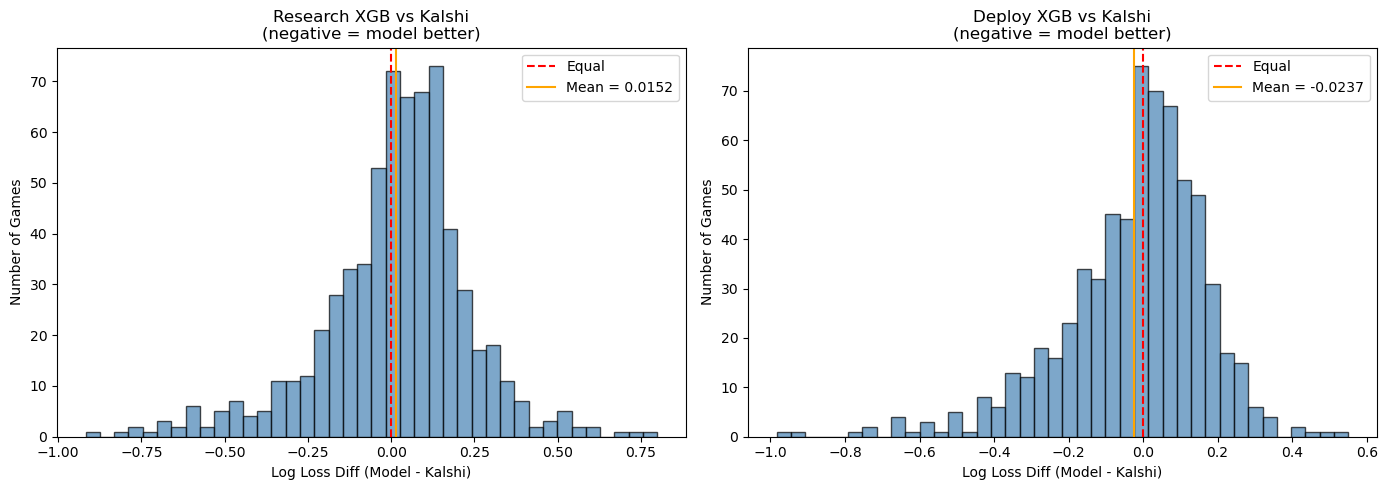

In [21]:
# Histogram of per-game log loss differences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, title) in zip(axes, [
    ('ll_diff_research', 'Research XGB vs Kalshi'),
    ('ll_diff_deploy', 'Deploy XGB vs Kalshi'),
]):
    vals = df[col].values
    ax.hist(vals, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal')
    ax.axvline(vals.mean(), color='orange', linestyle='-', linewidth=1.5,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_xlabel('Log Loss Diff (Model - Kalshi)')
    ax.set_ylabel('Number of Games')
    ax.set_title(f'{title}\n(negative = model better)')
    ax.legend()

plt.tight_layout()
plt.show()

## Step 5 — Calibration / Reliability Diagrams

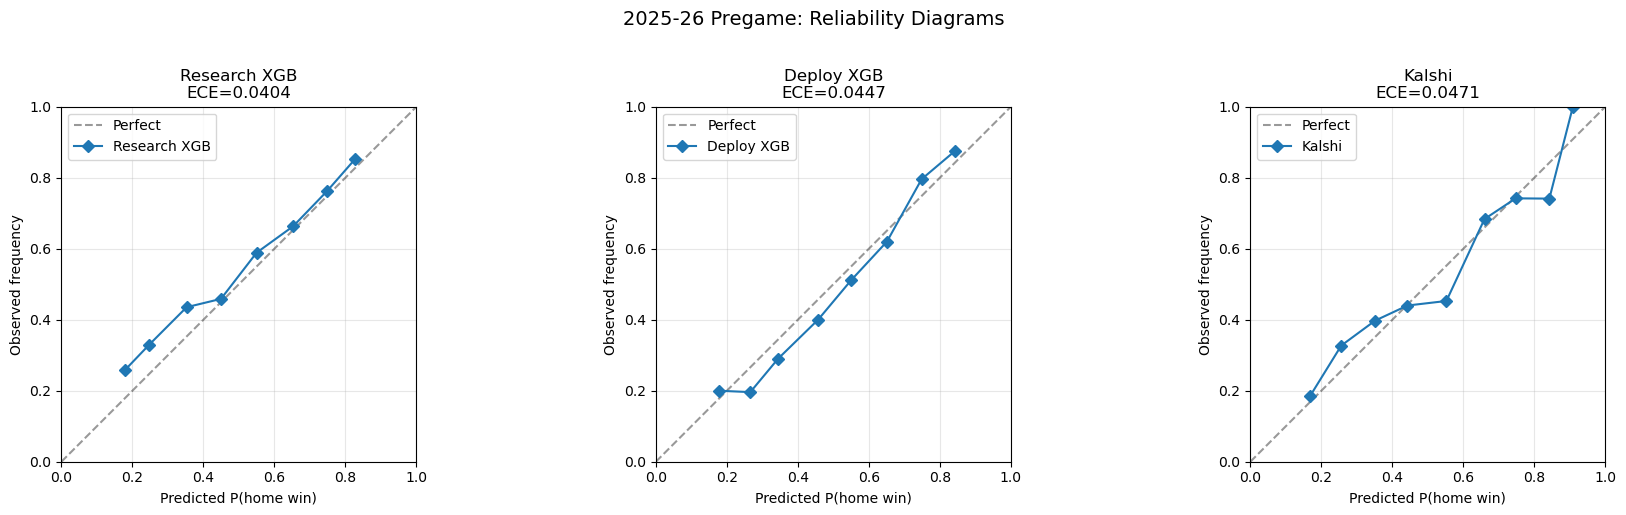

In [22]:
def reliability_curve(y, p, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    centers, empirical, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if mask.sum() < 3:
            continue
        centers.append(p[mask].mean())
        empirical.append(y[mask].mean())
        counts.append(mask.sum())
    return np.array(centers), np.array(empirical), np.array(counts)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, model_cols.items()):
    p = df[col].values
    c, e, n = reliability_curve(y, p)
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
    ax.plot(c, e, 'D-', markersize=6, label=name)
    ax.set_title(f'{name}\nECE={expected_calibration_error(y, p):.4f}')
    ax.set_xlabel('Predicted P(home win)')
    ax.set_ylabel('Observed frequency')
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('2025-26 Pregame: Reliability Diagrams', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 6 — Scatter: Model vs Kalshi Predictions

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


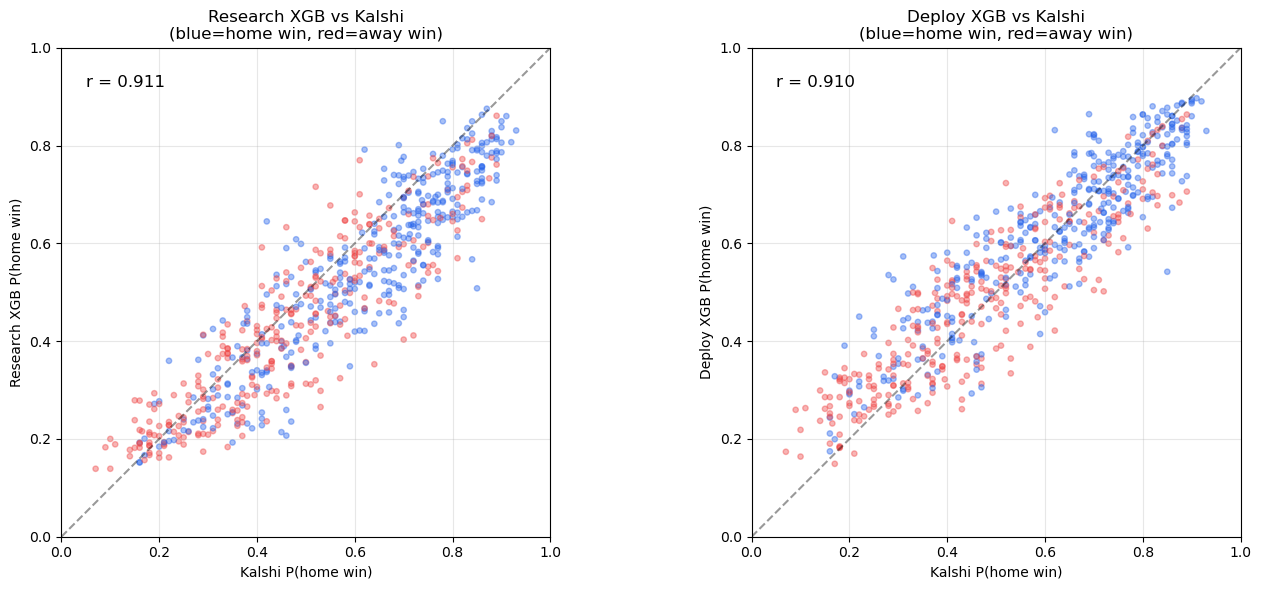

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (col, name) in zip(axes, [
    ('p_research', 'Research XGB'),
    ('p_deploy', 'Deploy XGB'),
]):
    colors = np.where(df['y'] == 1, '#2563eb', '#ef4444')
    ax.scatter(df['p_kalshi'], df[col], c=colors, alpha=0.4, s=15)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('Kalshi P(home win)')
    ax.set_ylabel(f'{name} P(home win)')
    ax.set_title(f'{name} vs Kalshi\n(blue=home win, red=away win)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Correlation
    corr = np.corrcoef(df['p_kalshi'], df[col])[0, 1]
    ax.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

## Step 7 — Analysis by Confidence Bucket

How does each model perform when it's confident (far from 0.5) vs uncertain?

In [24]:
# Bucket by Kalshi confidence
df['kalshi_conf'] = (df['p_kalshi'] - 0.5).abs()
df['conf_bucket'] = pd.cut(df['kalshi_conf'], bins=[0, 0.05, 0.1, 0.15, 0.2, 0.5],
                           labels=['Tossup (0-5%)', 'Lean (5-10%)', 'Moderate (10-15%)',
                                   'Confident (15-20%)', 'Strong (20%+)'])

bucket_rows = []
for bucket, sub in df.groupby('conf_bucket', observed=True):
    if len(sub) < 10:
        continue
    y_b = sub['y'].values
    for name, col in model_cols.items():
        p_b = sub[col].values
        bucket_rows.append({
            'Bucket': bucket,
            'Model': name,
            'N': len(sub),
            'LogLoss': log_loss(y_b, p_b),
            'Brier': brier_score_loss(y_b, p_b),
            'Accuracy': accuracy_score(y_b, (p_b >= 0.5).astype(int)),
        })

bucket_df = pd.DataFrame(bucket_rows)
print('=== Metrics by Kalshi Confidence Bucket ===\n')
print(bucket_df.to_string(index=False, float_format='%.5f'))

=== Metrics by Kalshi Confidence Bucket ===

            Bucket        Model   N  LogLoss   Brier  Accuracy
     Tossup (0-5%) Research XGB  76  0.71851 0.26117   0.50000
     Tossup (0-5%)   Deploy XGB  76  0.69948 0.25285   0.50000
     Tossup (0-5%)       Kalshi  76  0.69846 0.25266   0.43421
      Lean (5-10%) Research XGB 124  0.72837 0.26601   0.50000
      Lean (5-10%)   Deploy XGB 124  0.67299 0.24012   0.59677
      Lean (5-10%)       Kalshi 124  0.69101 0.24888   0.55645
 Moderate (10-15%) Research XGB  73  0.69884 0.25196   0.56164
 Moderate (10-15%)   Deploy XGB  73  0.65871 0.23299   0.64384
 Moderate (10-15%)       Kalshi  73  0.67733 0.24214   0.58904
Confident (15-20%) Research XGB 106  0.66398 0.23520   0.65094
Confident (15-20%)   Deploy XGB 106  0.59784 0.20577   0.69811
Confident (15-20%)       Kalshi 106  0.62515 0.21685   0.67925
     Strong (20%+) Research XGB 277  0.55536 0.18456   0.75812
     Strong (20%+)   Deploy XGB 277  0.52805 0.17389   0.75812
     Stron

## Step 8 — Biggest Disagreements

Games where the model and Kalshi most disagree — and who was right.

In [ ]:
df['disagree_deploy'] = (df['p_deploy'] - df['p_kalshi']).abs()

top_disagree = df.nlargest(100, 'disagree_deploy')[
    ['game_date', 'home_team', 'away_team', 'p_research', 'p_deploy', 'p_kalshi',
     'disagree_deploy', 'y', 'score_diff', 'll_research', 'll_deploy', 'll_kalshi', 'll_diff_deploy']
].copy()
top_disagree['game_date'] = top_disagree['game_date'].dt.strftime('%Y-%m-%d')
top_disagree['winner'] = np.where(
    top_disagree['ll_diff_deploy'] < 0, 'Model', 'Kalshi'
)

top_disagree = top_disagree[top_disagree['winner'] == 'Kalshi']

print('=== Top 20 Biggest Disagreements (Deploy XGB vs Kalshi) ===\n')
print(top_disagree.to_string(index=False, float_format='%.3f'))

model_wins = (top_disagree['winner'] == 'Model').sum()
print(f'\nModel wins {model_wins}/{len(top_disagree)} of biggest disagreements')

In [28]:
# Score-implied "true" probability: logistic(score_diff / SCALE)
# SCALE ≈ 1 std dev of NBA score margins; controls how aggressively
# blowouts translate to extreme probabilities.
SCALE = 12
df['p_true'] = 1 / (1 + np.exp(-df['score_diff'] / SCALE))

# Squared error from implied truth for each predictor
df['se_research'] = (df['p_research'] - df['p_true']) ** 2
df['se_deploy'] = (df['p_deploy'] - df['p_true']) ** 2
df['se_kalshi'] = (df['p_kalshi'] - df['p_true']) ** 2

# Positive edge = model closer to truth; negative = Kalshi closer
df['edge'] = df['se_kalshi'] - df['se_deploy']

# Worst games for our model: largest negative edge (Kalshi much closer to truth)
worst = df.nsmallest(30, 'edge')[
    ['game_date', 'home_team', 'away_team', 'p_research', 'p_deploy', 'p_kalshi',
     'p_true', 'se_research', 'se_deploy', 'se_kalshi', 'edge', 'score_diff']
].copy()
worst['game_date'] = worst['game_date'].dt.strftime('%Y-%m-%d')

print('=== 30 Worst Games for Model (conviction-weighted, Kalshi closest to truth) ===\n')
print(worst.to_string(index=False, float_format='%.3f'))

print(f'\n--- Overall ---')
print(f'Mean edge (+ = model better): {df["edge"].mean():.5f}')
print(f'Model closer to truth: {(df["edge"] > 0).sum()}/{len(df)} '
      f'({(df["edge"] > 0).mean():.1%})')
print(f'Mean |SE| research: {df["se_research"].mean():.4f}  deploy: {df["se_deploy"].mean():.4f}  Kalshi: {df["se_kalshi"].mean():.4f}')

=== 30 Worst Games for Model (conviction-weighted, Kalshi closest to truth) ===

 game_date home_team away_team  p_research  p_deploy  p_kalshi  p_true  se_research  se_deploy  se_kalshi   edge  score_diff
2026-02-03       MIL       CHI       0.236     0.306     0.470   0.791        0.309      0.236      0.103 -0.133          16
2025-11-25       PHI       ORL       0.441     0.526     0.380   0.032        0.167      0.244      0.121 -0.123         -41
2025-12-03       ATL       LAC       0.677     0.675     0.550   0.128        0.302      0.299      0.178 -0.121         -23
2025-12-25       LAL       HOU       0.540     0.599     0.460   0.128        0.170      0.221      0.110 -0.111         -23
2026-02-01       MIA       CHI       0.457     0.512     0.650   0.973        0.266      0.213      0.104 -0.108          43
2026-02-08       BOS        NY       0.585     0.693     0.600   0.138        0.200      0.308      0.214 -0.094         -22
2025-11-22       CHA       LAC       0.550  

## Step 9 — Monthly Trend

In [11]:
df['month'] = df['game_date'].dt.to_period('M')

monthly_rows = []
for month, sub in df.groupby('month'):
    y_m = sub['y'].values
    for name, col in model_cols.items():
        p_m = sub[col].values
        monthly_rows.append({
            'Month': str(month),
            'Model': name,
            'N': len(sub),
            'LogLoss': log_loss(y_m, p_m),
            'Brier': brier_score_loss(y_m, p_m),
            'Accuracy': accuracy_score(y_m, (p_m >= 0.5).astype(int)),
        })

monthly_df = pd.DataFrame(monthly_rows)
print('=== Metrics by Month ===\n')
print(monthly_df.to_string(index=False, float_format='%.5f'))

=== Metrics by Month ===

  Month        Model   N  LogLoss   Brier  Accuracy
2025-11 Research XGB 144  0.56641 0.19115   0.71528
2025-11   Deploy XGB 144  0.54075 0.18022   0.72222
2025-11       Kalshi 144  0.56102 0.19010   0.68750
2025-12 Research XGB 197  0.68335 0.24460   0.57868
2025-12   Deploy XGB 197  0.64622 0.22814   0.62437
2025-12       Kalshi 197  0.68198 0.24405   0.59391
2026-01 Research XGB 231  0.65966 0.23315   0.62338
2026-01   Deploy XGB 231  0.60469 0.20893   0.67100
2026-01       Kalshi 231  0.62888 0.21814   0.64502
2026-02 Research XGB  90  0.61354 0.21058   0.71111
2026-02   Deploy XGB  90  0.59042 0.20085   0.73333
2026-02       Kalshi  90  0.59226 0.20077   0.68889


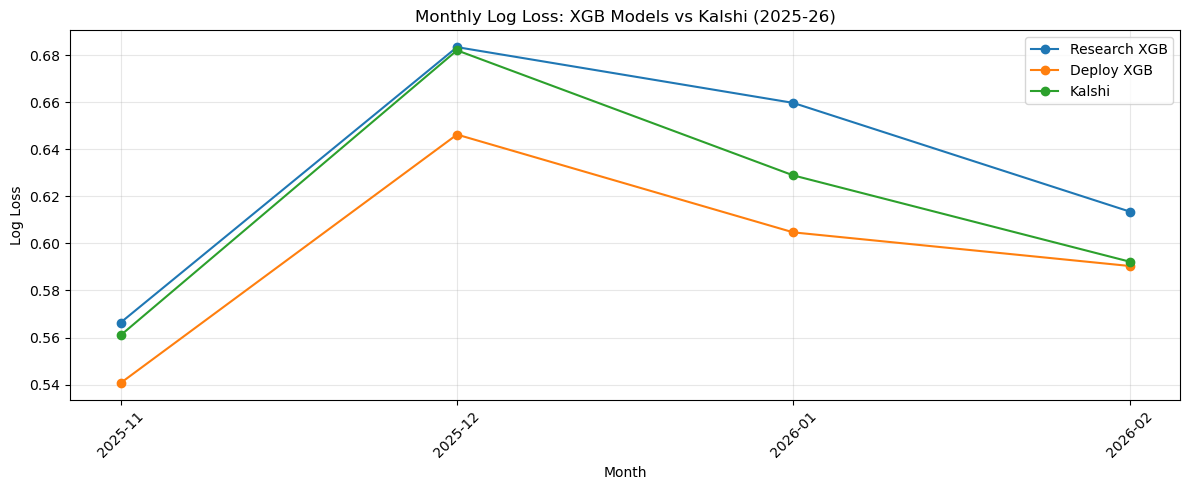

In [12]:
# Plot monthly log loss
fig, ax = plt.subplots(figsize=(12, 5))

for name, col in model_cols.items():
    sub = monthly_df[monthly_df['Model'] == name]
    ax.plot(sub['Month'], sub['LogLoss'], 'o-', label=name, markersize=6)

ax.set_xlabel('Month')
ax.set_ylabel('Log Loss')
ax.set_title('Monthly Log Loss: XGB Models vs Kalshi (2025-26)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary

In [13]:
print('=== Summary ===')
print(f'\nGames evaluated: {len(df)}')
print(f'Season: 2025-26')

print(f'\n--- Log Loss ---')
for name, col in model_cols.items():
    ll = log_loss(y, df[col].values)
    print(f'  {name:15s}: {ll:.5f}')

print(f'\n--- Brier Score ---')
for name, col in model_cols.items():
    bs = brier_score_loss(y, df[col].values)
    print(f'  {name:15s}: {bs:.5f}')

print(f'\n--- Accuracy ---')
for name, col in model_cols.items():
    acc = accuracy_score(y, (df[col].values >= 0.5).astype(int))
    print(f'  {name:15s}: {acc:.5f}')

# Note about data leakage
print(f'\n--- Important Notes ---')
print('  Research model: 2025-26 is the test season (never trained on)')
print('  Deploy model: trained ON 2025-26 data (includes these games)')
print('  Kalshi: market odds, fully out-of-sample')
print('  The fair comparison is Research XGB vs Kalshi (both out-of-sample)')

=== Summary ===

Games evaluated: 662
Season: 2025-26

--- Log Loss ---
  Research XGB   : 0.64016
  Deploy XGB     : 0.60120
  Kalshi         : 0.62494

--- Brier Score ---
  Research XGB   : 0.22435
  Deploy XGB     : 0.20730
  Kalshi         : 0.21739

--- Accuracy ---
  Research XGB   : 0.64199
  Deploy XGB     : 0.67674
  Kalshi         : 0.64502

--- Important Notes ---
  Research model: 2025-26 is the test season (never trained on)
  Deploy model: trained ON 2025-26 data (includes these games)
  Kalshi: market odds, fully out-of-sample
  The fair comparison is Research XGB vs Kalshi (both out-of-sample)


In [ ]:
# Save games where Deploy XGB differs from Kalshi by more than 5%
disagree_df = df[df['disagree_deploy'] > 0.05][
    ['game_id', 'game_date', 'home_team', 'away_team',
     'p_deploy', 'p_kalshi', 'disagree_deploy', 'y', 'score_diff',
     'll_deploy', 'll_kalshi', 'll_diff_deploy']
].copy()
disagree_df = disagree_df.sort_values('disagree_deploy', ascending=False)
disagree_df['game_date'] = disagree_df['game_date'].dt.strftime('%Y-%m-%d')

out_path = DATA_DIR / 'prior_disagree_deploy_vs_kalshi.csv'
disagree_df.to_csv(out_path, index=False)

model_better = (disagree_df['ll_diff_deploy'] < 0).sum()d
print(f'Games with >5% disagreement: {len(disagree_df)}')
print(f'Model better: {model_better} ({model_better/len(disagree_df):.1%})')
print(f'Kalshi better: {len(disagree_df) - model_better} ({1 - model_better/len(disagree_df):.1%})')
print(f'Mean disagreement: {disagree_df["disagree_deploy"].mean():.3f}')
print(f'\nSaved to {out_path}')

Games with >5% disagreement: 389
Model better: 189 (48.6%)
Kalshi better: 200 (51.4%)
Mean disagreement: 0.103

Saved to data/prior_disagree_deploy_vs_kalshi.csv
